<a href="https://colab.research.google.com/github/polymatheiia/ML2025L/blob/main/solutions/homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework assignment №1
## Author: Danuta Grabovska


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

First step we need to do is to import our data and have a look at it.

In [ ]:
data = pd.read_csv('datasets/PCA_three_clusters_data.csv')
data.head(5)

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0


Our next step is to perform the Principal Component analysis to find the first two principal components to be able to plot it later.

In [ ]:
X = data.drop(['class'],axis=1).values
y = data['class'].values

# Center and standardize the data before applying PCA
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Perform PCA and reduce the data to 2 components for visualization
pca = PCA(n_components = 2)
XV = pca.fit_transform(X)

print("\nTwo principal directions in rows\n")
print(pca.components_)

print("\nX projected on V (first 5 rows)\n")
print(XV[:5,:])
print("\nExplained percentage variance\n")
print(pca.explained_variance_ratio_)
print("\nCumulative explained percentage variance\n")
print(np.cumsum(pca.explained_variance_ratio_))


Two principal directions in rows

[[ 0.72005783  0.56946    -0.39652494]
 [-0.02368275  0.59126692  0.80612813]]

X projected on V (first 5 rows)

[[-1.12582206  0.05986874]
 [-1.89368654  0.95808305]
 [-1.61886158  1.39907438]
 [-1.61654666 -0.01318696]
 [-2.41865284 -0.83294294]]

Explained percentage variance

[0.34722276 0.33441835]

Cumulative explained percentage variance

[0.34722276 0.68164111]


We can already see that cumulative explained variance is roughly 2/3, which is not an impressive result, given 3 variables. We still don't know how our data looks like, so let's visualize both PCA components and the data itself.

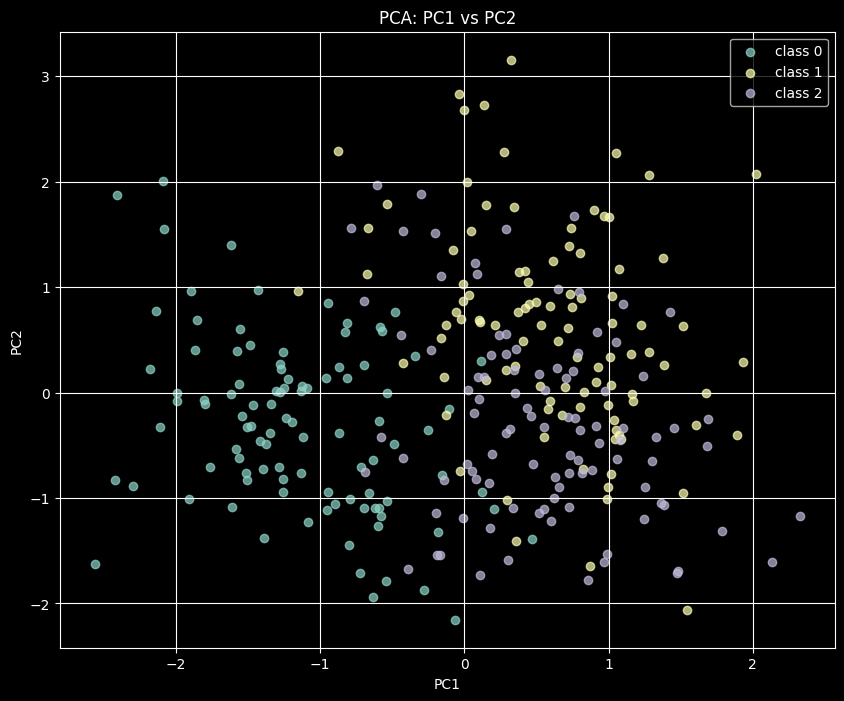

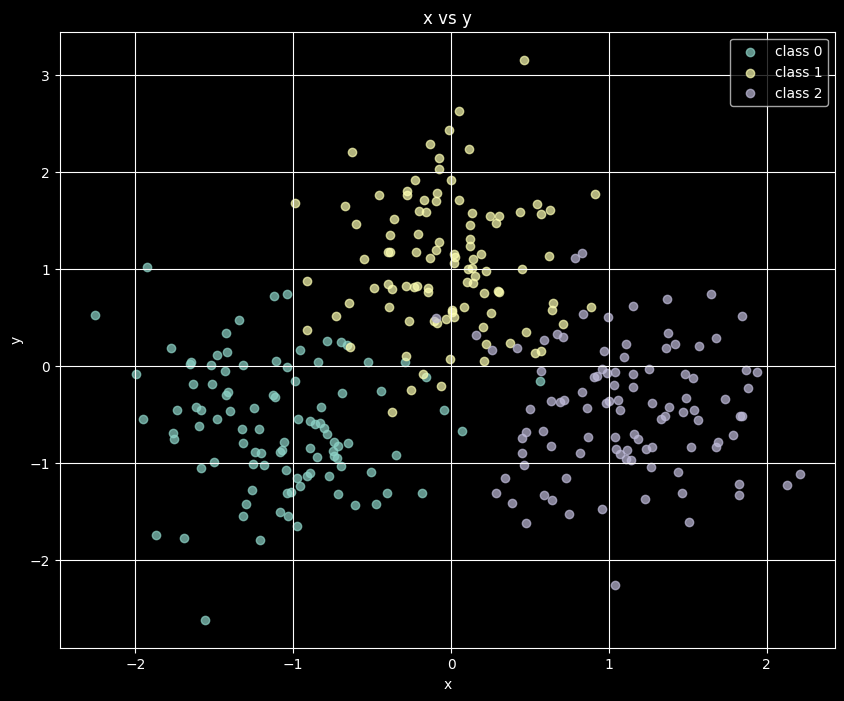

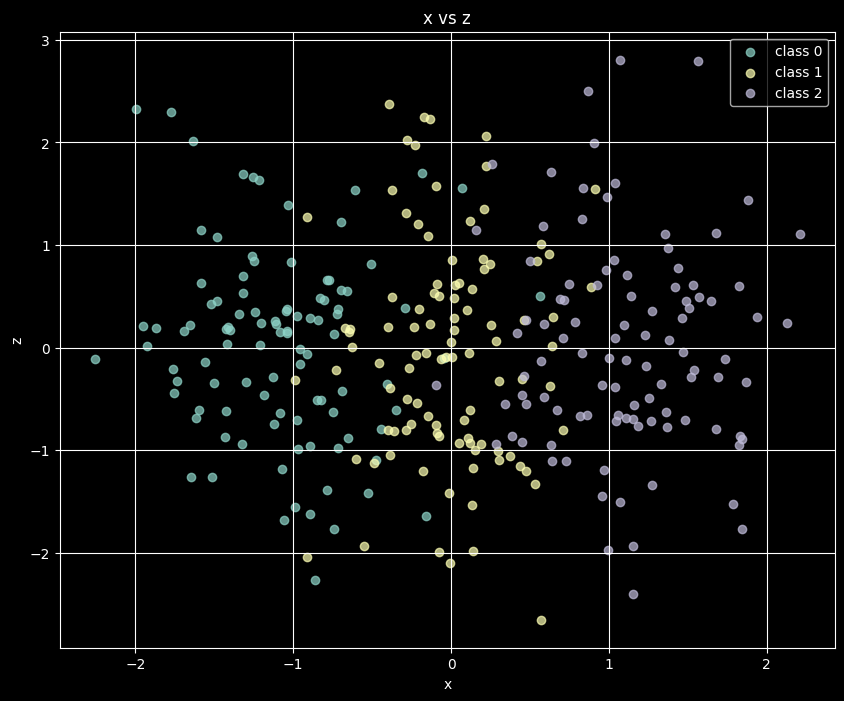

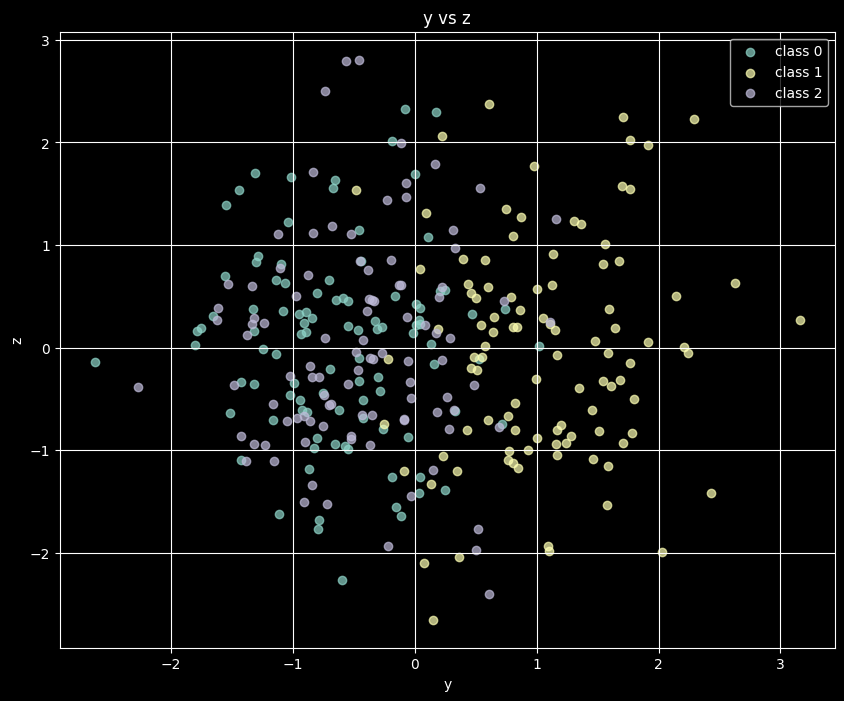

In [ ]:
plt.figure(figsize=(10,8))
for c in np.unique(y):
    plt.scatter(XV[y==c,0], XV[y==c,1], label=f"class {c}", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,8))
for c in np.unique(y):
    plt.scatter(X[y==c,0], X[y==c,1], label=f"class {c}", alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,8))
for c in np.unique(y):
    plt.scatter(X[y==c,0], X[y==c,2], label=f"class {c}", alpha=0.7)
plt.xlabel("x")
plt.ylabel("z")
plt.title("x vs z")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,8))
for c in np.unique(y):
    plt.scatter(X[y==c,1], X[y==c,2], label=f"class {c}", alpha=0.7)
plt.xlabel("y")
plt.ylabel("z")
plt.title("y vs z")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(X, columns=["x","y","z"])
df["class"] = y

fig = px.scatter_3d(df, x="x", y="y", z="z", color="class")
fig.show()

Judging from the plots, we can clearly see that the x vs y plot does a way better job separating the data into different clusters than PCA. That is a shame, because that would mean PCA is useless for this dataset. Let's investigate why:

In [ ]:
fig = go.Figure()

for c in np.unique(y):
    d = df[df["class"] == c]
    fig.add_trace(go.Scatter3d(
        x=d["x"],
        y=d["y"],
        z=d["z"],
        mode="markers",
        name=f"class {c}",
        marker=dict(size=4)
    ))

center = X.mean(axis=0)

components = pca.components_
variances = pca.explained_variance_

scale = 3

for i in range(2):
    direction = components[i]
    vec = direction * variances[i] * scale

    fig.add_trace(go.Scatter3d(
        x=[center[0], center[0] + vec[0]],
        y=[center[1], center[1] + vec[1]],
        z=[center[2], center[2] + vec[2]],
        mode="lines+markers",
        name=f"PC{i+1}",
        line=dict(width=8)
    ))

fig.add_trace(go.Scatter3d(
    x=[center[0]],
    y=[center[1]],
    z=[center[2]],
    mode="markers",
    name="mean",
    marker=dict(size=6)
))

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z"
    ),
    title="3D Data with PCA Directions"
)

fig.show()

Here we visualized our dataset along with both principal components' directions. This is actually interesting, because given the shape of data (three "columns" stretched by z axis), the clustering would be performed the best by just looking at XY projection. However, PCA finds directions that maximize variance rather than directions that best separate clusters. Because the dataset shows substantial variation along the z-axis, the principal components are influenced by this dimension and partially align with it. As a result, PCA does not focus purely on the XY plane, even though that projection would separate the clusters more clearly.

Secondary question: what if we don't standardize the data and plot it as it is?

In [ ]:
df = pd.DataFrame(X, columns=["x","y","z"])
df["class"] = y

fig = px.scatter_3d(df, x="x", y="y", z="z", color="class")
fig.show()

fig = px.scatter_3d(data, x="x", y="y", z="z", color="class")
fig.show()

In our case (where z-axis variance is actually already a bit of a hindrance), forgetting about standardization might cause the components to align with z axis even more to reflect its huge variance. As it was shown above, it is not exactly (in our case actually the complete opposite of) our goal, therefore standardization is ensuring that PCA "treats equally" all variables and their respective variances.